# Thermocouple Calibration

This notebook keeps the calibration record concise and channel-first.

- Raw logger CSV files remain raw. Notebooks and the supervisor UI apply calibration in memory.
- The firmware thermocouple type fix boundary is `2026-04-20 11:15:45`.
- Logger channel U8 is the colder heat-exchanger channel `THM`; U9 is `THI`.
- April 10 is retained as a historical diagnostic because Type T probes were still decoded as Type K.
- April 20 provides the main Type T calibration after the firmware fix.
- May 7 adds the installed `THM`/`THI` room + warmup-transfer fit to the active April 20 table.

In [ ]:

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data' / 'raw').exists() and (candidate / 'analysis' / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root.')


repo_root = find_repo_root()
analysis_src = repo_root / 'analysis' / 'src'
if str(analysis_src) not in sys.path:
    sys.path.insert(0, str(analysis_src))

from orca.logbook import apply_tc_calibration, canonicalize_tc_columns

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

LN2_BP_C = -195.8
ROOM_REFERENCE_F = 68.5
ROOM_REFERENCE_C = (ROOM_REFERENCE_F - 32.0) * 5.0 / 9.0
TC_COLUMNS = ['TTEST_C', 'TFO_C', 'TTI_C', 'TTO_C', 'TMI_C', 'THM_C', 'THI_C']
TC_ORDER = ['TTEST', 'TFO', 'TTI', 'TNO', 'TTO', 'TMI', 'THM', 'THI']
COLORS = dict(zip(TC_COLUMNS, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']))
COLORS['TNO_C'] = 'C7'

CALIBRATION_DIR = repo_root / 'data' / 'processed' / 'calibration'
APR10_LOG = repo_root / 'data' / 'raw' / 'calibration' / 'log_20260410_145703.csv'
APR20_LOG = repo_root / 'data' / 'raw' / 'calibration' / 'log_20260420_111545.csv'
MAY7_TRANSFER_LOG = repo_root / 'data' / 'raw' / 'recirculation' / 'log_20260424_153546.csv'
ACTIVE_EXPORT = CALIBRATION_DIR / 'TC_calibration_20260420.csv'
APR10_EXPORT = CALIBRATION_DIR / 'TC_calibration_20260410.csv'


def load_tc_log(path: Path) -> pd.DataFrame:
    data = canonicalize_tc_columns(pd.read_csv(path, comment='#'))
    data['time_s'] = pd.to_numeric(data['time_s'], errors='coerce')
    for column in [*TC_COLUMNS, 'valve', 'pump_cmd_pct', 'fluid_temperature_c']:
        if column in data.columns:
            data[column] = pd.to_numeric(data[column], errors='coerce')
    data = data.dropna(subset=['time_s']).sort_values('time_s').reset_index(drop=True)
    data['t_rel_min'] = (data['time_s'] - float(data['time_s'].iloc[0])) / 60.0
    return data


def window_median(data: pd.DataFrame, column: str, window: tuple[float, float]) -> float:
    mask = data['time_s'].between(window[0], window[1])
    return float(data.loc[mask, column].median())


def two_point(raw_room_c: float, raw_cold_c: float, true_room_c: float, true_cold_c: float) -> tuple[float, float]:
    gain = (true_cold_c - true_room_c) / (raw_cold_c - raw_room_c)
    offset = true_room_c - gain * raw_room_c
    return float(gain), float(offset)


def build_calibration_table(
    data: pd.DataFrame,
    *,
    room_window: tuple[float, float],
    ln_windows: dict[str, tuple[float, float]],
    room_only_columns: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    room_raw = {
        column: window_median(data, column, room_window)
        for column in TC_COLUMNS
        if column in data.columns
    }
    rows = []
    anchors = []
    for column in TC_COLUMNS:
        tag = column.removesuffix('_C')
        raw_room = room_raw[column]
        anchors.append({'TC': tag, 'anchor': 'room', 'raw_C': raw_room, 'true_C': ROOM_REFERENCE_C})
        if column in ln_windows:
            raw_ln = window_median(data, column, ln_windows[column])
            gain, offset = two_point(raw_room, raw_ln, ROOM_REFERENCE_C, LN2_BP_C)
            cal_type = 'two-point'
            anchors.append({'TC': tag, 'anchor': 'LN2', 'raw_C': raw_ln, 'true_C': LN2_BP_C})
        elif column in room_only_columns:
            raw_ln = np.nan
            gain = 1.0
            offset = ROOM_REFERENCE_C - raw_room
            cal_type = 'room-only'
        else:
            raw_ln = np.nan
            gain = 1.0
            offset = ROOM_REFERENCE_C - raw_room
            cal_type = 'room-only'
        rows.append({
            'TC': tag,
            'raw_room_C': raw_room,
            'raw_cold_C': raw_ln,
            'gain': gain,
            'offset_C': offset,
            'cal_type': cal_type,
        })
    return pd.DataFrame(rows), pd.DataFrame(anchors)


def plot_raw_session(data: pd.DataFrame, title: str, windows: dict[str, tuple[float, float]], room_window: tuple[float, float]):
    fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
    for column in TC_COLUMNS:
        if column in data.columns:
            ax.plot(data['t_rel_min'], data[column], lw=0.9, color=COLORS[column], label=column.removesuffix('_C'))
    t0 = float(data['time_s'].iloc[0])
    ax.axvspan((room_window[0] - t0) / 60.0, (room_window[1] - t0) / 60.0, color='green', alpha=0.12, label='room anchor')
    for column, window in windows.items():
        ax.axvspan((window[0] - t0) / 60.0, (window[1] - t0) / 60.0, color=COLORS.get(column, '0.5'), alpha=0.12)
    ax.axhline(ROOM_REFERENCE_C, color='green', ls='--', lw=0.9, alpha=0.7)
    ax.axhline(LN2_BP_C, color='navy', ls='--', lw=0.9, alpha=0.7)
    ax.set_xlabel('Time from log start [min]')
    ax.set_ylabel('Temperature [C]')
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=4)
    return fig


def plot_calibration_curves(
    table: pd.DataFrame,
    anchors: pd.DataFrame,
    title: str,
    *,
    columns: list[str] | None = None,
    raw_limits: tuple[float, float] | None = None,
):
    selected = table.copy()
    if columns is not None:
        selected = selected[selected['TC'].isin(columns)]
    if raw_limits is None:
        raw_min = float(np.nanmin([selected['raw_room_C'].min(), selected['raw_cold_C'].min()])) - 5.0
        raw_max = float(np.nanmax([selected['raw_room_C'].max(), selected['raw_cold_C'].max()])) + 5.0
    else:
        raw_min, raw_max = raw_limits
    raw_grid = np.linspace(raw_min, raw_max, 400)
    fig, ax = plt.subplots(figsize=(8.2, 5.8), constrained_layout=True)
    for _, row in selected.iterrows():
        column = f"{row['TC']}_C"
        line_style = '--' if row['cal_type'] == 'room-only' else '-'
        ax.plot(raw_grid, row['gain'] * raw_grid + row['offset_C'], line_style, lw=1.8, color=COLORS.get(column, '0.4'), label=row['TC'])
        tc_anchors = anchors[anchors['TC'].eq(row['TC'])]
        for _, anchor in tc_anchors.iterrows():
            marker = 'o' if anchor['anchor'] == 'room' else 's'
            ax.scatter(anchor['raw_C'], anchor['true_C'], color=COLORS.get(column, '0.4'), marker=marker, s=48, zorder=4)
    ax.axline((0, 0), slope=1.0, color='0.65', lw=0.9, ls=':', label='unity')
    ax.set_xlabel('Raw temperature [C]')
    ax.set_ylabel('Calibrated temperature [C]')
    ax.set_xlim(raw_min, raw_max)
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    return fig


def export_table(table: pd.DataFrame, path: Path) -> pd.DataFrame:
    export = table[['TC', 'gain', 'offset_C', 'cal_type']].copy()
    export['TC'] = pd.Categorical(export['TC'], categories=TC_ORDER, ordered=True)
    export = export.sort_values('TC').reset_index(drop=True)
    export['TC'] = export['TC'].astype(str)
    path.parent.mkdir(parents=True, exist_ok=True)
    export.to_csv(path, index=False)
    return export

print(f'Repo root: {repo_root}')
print(f'Room reference: {ROOM_REFERENCE_F:.1f} F = {ROOM_REFERENCE_C:.3f} C')


## April 10, 2026: Historical First Pass

`log_20260410_145703.csv` is useful as a record of the first calibration attempt, but it is not the active calibration. The firmware was still decoding Type T probes with the Type K table, so the Type T low-temperature plateaus are physically wrong in temperature space. The exported `TC_calibration_20260410.csv` is retained only as a historical diagnostic.

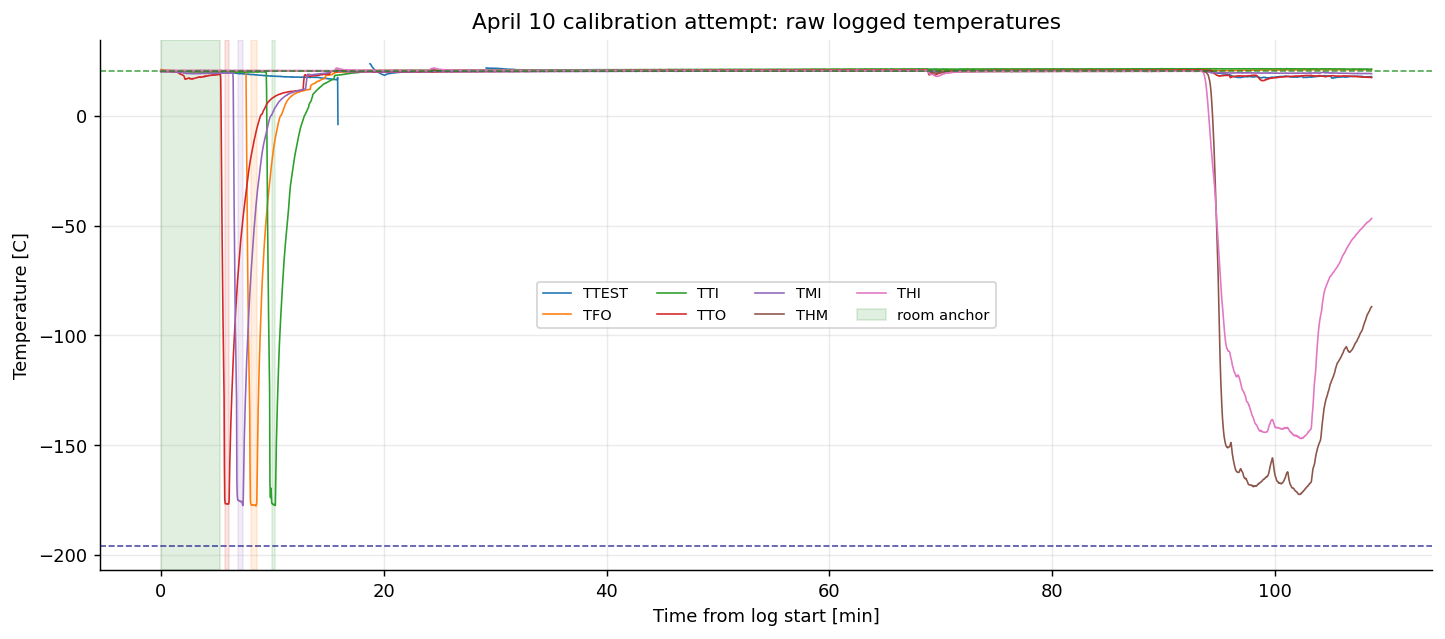

TC,raw_room_C,raw_cold_C,gain,offset_C,cal_type
TTEST,20.050,nan,1.000000,+0.227778,room-only
TFO,20.050,-177.200,1.095451,-1.686022,two-point
TTI,19.990,-176.855,1.097705,-1.665349,two-point
TTO,18.430,-176.590,1.107978,-0.142248,two-point
TMI,19.290,-175.460,1.109514,-1.124740,two-point
THM,20.480,nan,1.000000,-0.202222,room-only
THI,20.520,nan,1.000000,-0.242222,room-only


Saved historical April 10 table -> data/processed/calibration/TC_calibration_20260410.csv


In [2]:

apr10 = load_tc_log(APR10_LOG)
APR10_ROOM_WINDOW = (188_424, 188_745)
APR10_LN_WINDOWS = {
    'TTO_C': (188_771, 188_791),
    'TMI_C': (188_840, 188_867),
    'TFO_C': (188_909, 188_940),
    'TTI_C': (189_023, 189_041),
}

fig = plot_raw_session(apr10, 'April 10 calibration attempt: raw logged temperatures', APR10_LN_WINDOWS, APR10_ROOM_WINDOW)
plt.show()
apr10_table, apr10_anchors = build_calibration_table(
    apr10,
    room_window=APR10_ROOM_WINDOW,
    ln_windows=APR10_LN_WINDOWS,
    room_only_columns=['TTEST_C', 'THM_C', 'THI_C'],
)
apr10_export = export_table(apr10_table, APR10_EXPORT)

summary = apr10_table[['TC', 'raw_room_C', 'raw_cold_C', 'gain', 'offset_C', 'cal_type']].copy()
display(summary.style.format({
    'raw_room_C': '{:.3f}',
    'raw_cold_C': '{:.3f}',
    'gain': '{:.6f}',
    'offset_C': '{:+.6f}',
}).hide(axis='index'))
print(f'Saved historical April 10 table -> {APR10_EXPORT.relative_to(repo_root)}')


## April 20, 2026: Main Calibration After Type Fix

`log_20260420_111545.csv` was recorded after the per-channel thermocouple types were corrected in firmware. The room anchor is the flat final five minutes of the log. The active Type T rows use room + LN2 two-point fits; the future `TTI` row uses the longer replacement probe dip. The earlier dip of the originally installed `TTI` probe is compared below to confirm it agrees with the longer probe on the same electronics. `THM` and `THI` had no defensible cold bath plateau in this run, so they are placeholders here and are replaced in the May 7 transfer section.

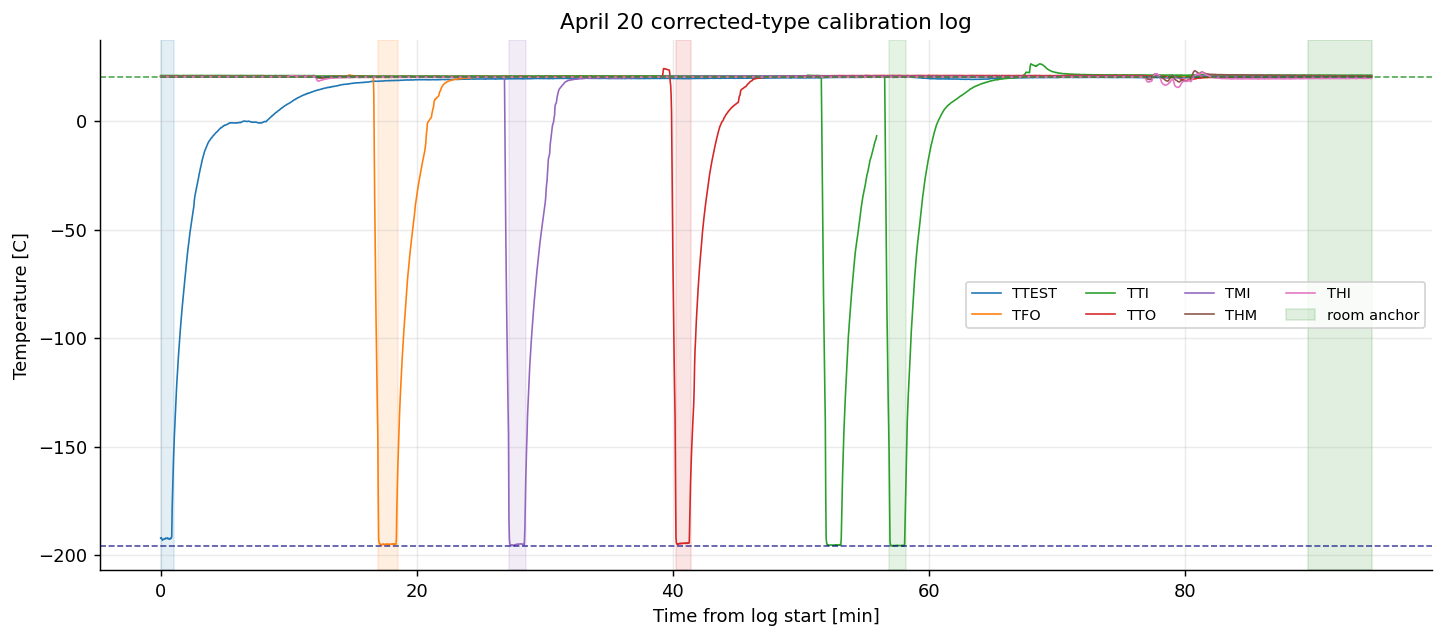

TC,raw_room_C,raw_cold_C,gain,offset_C,cal_type
TTEST,20.330,-192.265,1.016382,-0.385273,two-point
TFO,20.870,-194.860,1.001612,-0.625867,two-point
TTI,21.230,-195.465,0.997152,-0.891752,two-point
TTO,20.340,-194.410,1.006183,-0.187982,two-point
TMI,20.400,-194.905,1.003589,-0.195442,two-point
THM,20.920,nan,1.000000,-0.642222,room-only
THI,19.690,nan,1.000000,+0.587778,room-only


probe,room_window_s,ln_window_s,raw_room_C,raw_ln_C,gain,offset_C,cal_at_raw_-100_C,cal_at_raw_-200_C,exported
TTI original installed probe,3000-3200,3291-3372,20.910,-195.240,0.999666,-0.625236,-100.592,-200.558,False
TTI longer replacement probe,5549-5849,3588-3668,21.230,-195.465,0.997152,-0.891752,-100.607,-200.322,True


raw_LN_long_minus_original_C,gain_long_minus_original_pct,cal_at_raw_-100_long_minus_original_C,cal_at_raw_-200_long_minus_original_C
-0.225,-0.252,-0.015,+0.236


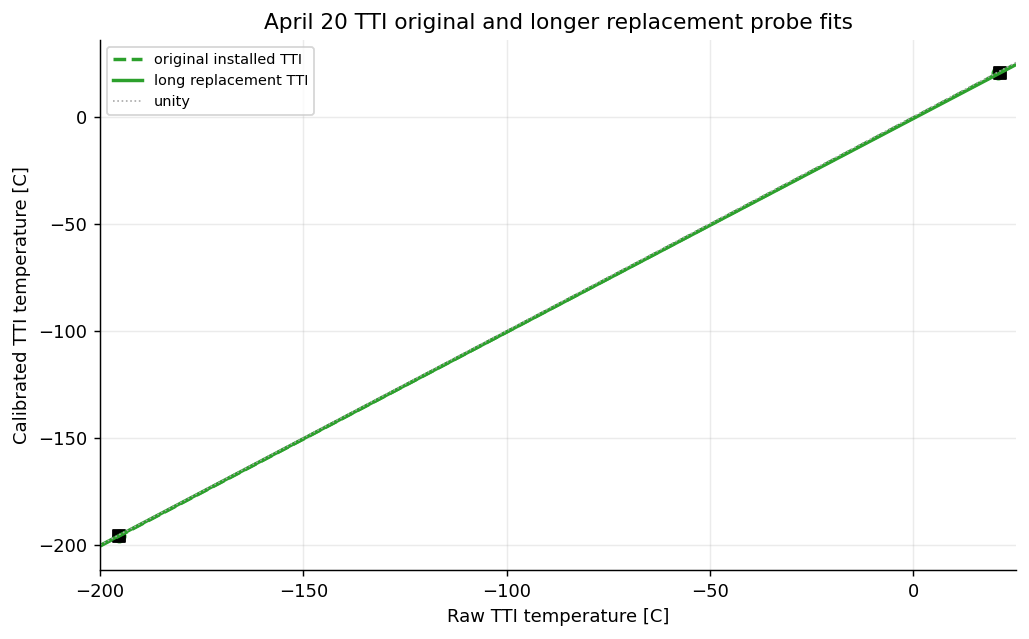

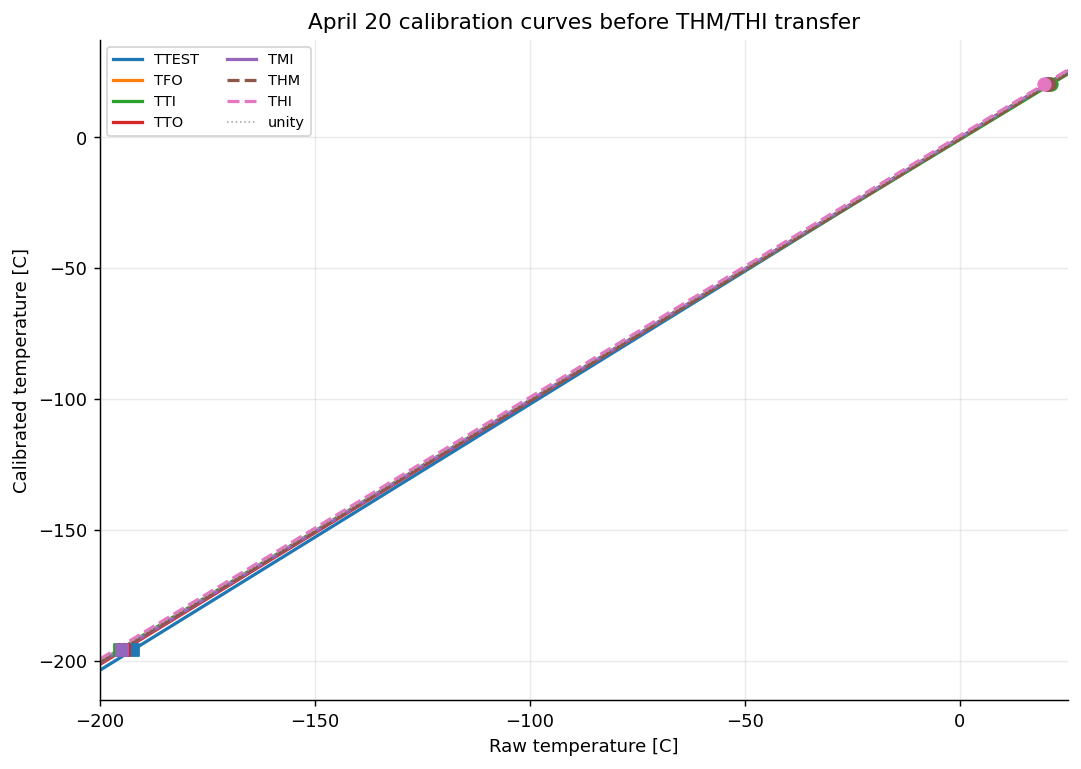

In [3]:

apr20 = load_tc_log(APR20_LOG)
APR20_ROOM_WINDOW = (float(apr20['time_s'].iloc[-1]) - 300.0, float(apr20['time_s'].iloc[-1]))
APR20_LN_WINDOWS = {
    'TTEST_C': (173.366, 233.590),
    'TFO_C': (1193.035, 1286.489),
    'TMI_C': (1805.669, 1886.661),
    'TTO_C': (2586.518, 2661.280),
    'TTI_C': (3587.502, 3668.493),
}
APR20_TTI_ORIGINAL_ROOM_WINDOW = (3000.0, 3200.0)
APR20_TTI_ORIGINAL_LN_WINDOW = (3290.528, 3371.522)

fig = plot_raw_session(apr20, 'April 20 corrected-type calibration log', APR20_LN_WINDOWS, APR20_ROOM_WINDOW)
plt.show()
apr20_base_table, apr20_base_anchors = build_calibration_table(
    apr20,
    room_window=APR20_ROOM_WINDOW,
    ln_windows=APR20_LN_WINDOWS,
    room_only_columns=['THM_C', 'THI_C'],
)

# TTI was first dipped with the originally installed probe, then replaced by a longer
# Type T probe on the same electronics. Check that the two LN calibrations agree.
tti_original_room = window_median(apr20, 'TTI_C', APR20_TTI_ORIGINAL_ROOM_WINDOW)
tti_original_ln = window_median(apr20, 'TTI_C', APR20_TTI_ORIGINAL_LN_WINDOW)
tti_original_gain, tti_original_offset = two_point(tti_original_room, tti_original_ln, ROOM_REFERENCE_C, LN2_BP_C)

tti_long_room = window_median(apr20, 'TTI_C', APR20_ROOM_WINDOW)
tti_long_ln = window_median(apr20, 'TTI_C', APR20_LN_WINDOWS['TTI_C'])
tti_long_gain = float(apr20_base_table.loc[apr20_base_table['TC'].eq('TTI'), 'gain'].iloc[0])
tti_long_offset = float(apr20_base_table.loc[apr20_base_table['TC'].eq('TTI'), 'offset_C'].iloc[0])

tti_compare = pd.DataFrame([
    {
        'probe': 'TTI original installed probe',
        'room_window_s': f'{APR20_TTI_ORIGINAL_ROOM_WINDOW[0]:.0f}-{APR20_TTI_ORIGINAL_ROOM_WINDOW[1]:.0f}',
        'ln_window_s': f'{APR20_TTI_ORIGINAL_LN_WINDOW[0]:.0f}-{APR20_TTI_ORIGINAL_LN_WINDOW[1]:.0f}',
        'raw_room_C': tti_original_room,
        'raw_ln_C': tti_original_ln,
        'gain': tti_original_gain,
        'offset_C': tti_original_offset,
        'cal_at_raw_-100_C': tti_original_gain * -100.0 + tti_original_offset,
        'cal_at_raw_-200_C': tti_original_gain * -200.0 + tti_original_offset,
        'exported': False,
    },
    {
        'probe': 'TTI longer replacement probe',
        'room_window_s': f'{APR20_ROOM_WINDOW[0]:.0f}-{APR20_ROOM_WINDOW[1]:.0f}',
        'ln_window_s': f"{APR20_LN_WINDOWS['TTI_C'][0]:.0f}-{APR20_LN_WINDOWS['TTI_C'][1]:.0f}",
        'raw_room_C': tti_long_room,
        'raw_ln_C': tti_long_ln,
        'gain': tti_long_gain,
        'offset_C': tti_long_offset,
        'cal_at_raw_-100_C': tti_long_gain * -100.0 + tti_long_offset,
        'cal_at_raw_-200_C': tti_long_gain * -200.0 + tti_long_offset,
        'exported': True,
    },
])
tti_delta = pd.DataFrame([{
    'raw_LN_long_minus_original_C': tti_long_ln - tti_original_ln,
    'gain_long_minus_original_pct': 100.0 * (tti_long_gain - tti_original_gain) / tti_original_gain,
    'cal_at_raw_-100_long_minus_original_C': tti_compare.loc[1, 'cal_at_raw_-100_C'] - tti_compare.loc[0, 'cal_at_raw_-100_C'],
    'cal_at_raw_-200_long_minus_original_C': tti_compare.loc[1, 'cal_at_raw_-200_C'] - tti_compare.loc[0, 'cal_at_raw_-200_C'],
}])

display(apr20_base_table[['TC', 'raw_room_C', 'raw_cold_C', 'gain', 'offset_C', 'cal_type']].style.format({
    'raw_room_C': '{:.3f}',
    'raw_cold_C': '{:.3f}',
    'gain': '{:.6f}',
    'offset_C': '{:+.6f}',
}).hide(axis='index'))
display(tti_compare.style.format({
    'raw_room_C': '{:.3f}',
    'raw_ln_C': '{:.3f}',
    'gain': '{:.6f}',
    'offset_C': '{:+.6f}',
    'cal_at_raw_-100_C': '{:.3f}',
    'cal_at_raw_-200_C': '{:.3f}',
}).hide(axis='index'))
display(tti_delta.style.format({
    'raw_LN_long_minus_original_C': '{:+.3f}',
    'gain_long_minus_original_pct': '{:+.3f}',
    'cal_at_raw_-100_long_minus_original_C': '{:+.3f}',
    'cal_at_raw_-200_long_minus_original_C': '{:+.3f}',
}).hide(axis='index'))

raw_grid_tti = np.linspace(-200.0, ROOM_REFERENCE_C + 5.0, 400)
fig, ax = plt.subplots(figsize=(7.8, 4.8), constrained_layout=True)
ax.plot(raw_grid_tti, tti_original_gain * raw_grid_tti + tti_original_offset, color=COLORS['TTI_C'], ls='--', lw=1.9, label='original installed TTI')
ax.plot(raw_grid_tti, tti_long_gain * raw_grid_tti + tti_long_offset, color=COLORS['TTI_C'], ls='-', lw=1.9, label='long replacement TTI')
ax.scatter([tti_original_room, tti_original_ln], [ROOM_REFERENCE_C, LN2_BP_C], color=COLORS['TTI_C'], marker='o', s=45)
ax.scatter([tti_long_room, tti_long_ln], [ROOM_REFERENCE_C, LN2_BP_C], color='black', marker='s', s=42)
ax.axline((0, 0), slope=1.0, color='0.65', lw=0.9, ls=':', label='unity')
ax.set_xlim(-200.0, ROOM_REFERENCE_C + 5.0)
ax.set_xlabel('Raw TTI temperature [C]')
ax.set_ylabel('Calibrated TTI temperature [C]')
ax.set_title('April 20 TTI original and longer replacement probe fits')
ax.legend(fontsize=8)
plt.show()

fig = plot_calibration_curves(
    apr20_base_table,
    apr20_base_anchors,
    'April 20 calibration curves before THM/THI transfer',
    raw_limits=(-200.0, ROOM_REFERENCE_C + 5.0),
)
plt.show()


## May 7, 2026: THM/THI Warmup-Transfer Fit

The installed HX probes cannot be calibrated from a partial LN dip. The practical calibration used here is a two-point, channel-first fit:

1. room anchor from the April 20 flat-tail room window,
2. warmup-transfer anchor from `log_20260424_153546.csv` after cooldown stops, using the calibrated loop probes as the local reference near `-35 C`.

The April 24 file used here is the restored raw CSV, so the fit is tied to hardware position: U8 -> `THM_C`, U9 -> `THI_C`.

source_log,cooldown_stop_min,transfer_start_min,pump_off_min,band_samples,loop_reference_C,loop_span_median_C,TTI_band_low_C,TTI_band_high_C
data/raw/recirculation/log_20260424_153546.csv,174.13,179.13,273.08,78,-35.0400,0.3900,-35.5,-34.5


TC,raw_room_C,raw_cold_C,gain,offset_C,cal_type,room_check_C,warmup_check_C
THM,20.9200,-34.9528,0.990066718500,-0.434417973250,room+warmup-transfer,20.2778,-35.0400
THI,19.6900,-32.1378,1.067338406509,-0.738115446382,room+warmup-transfer,20.2778,-35.0400


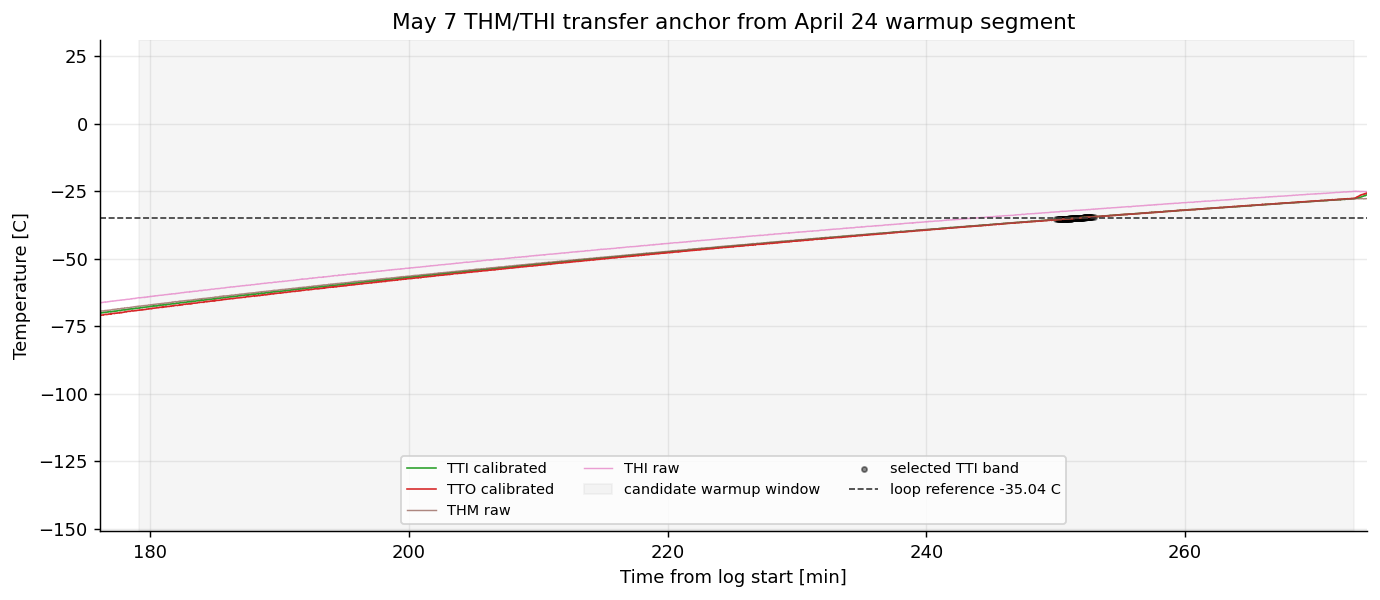

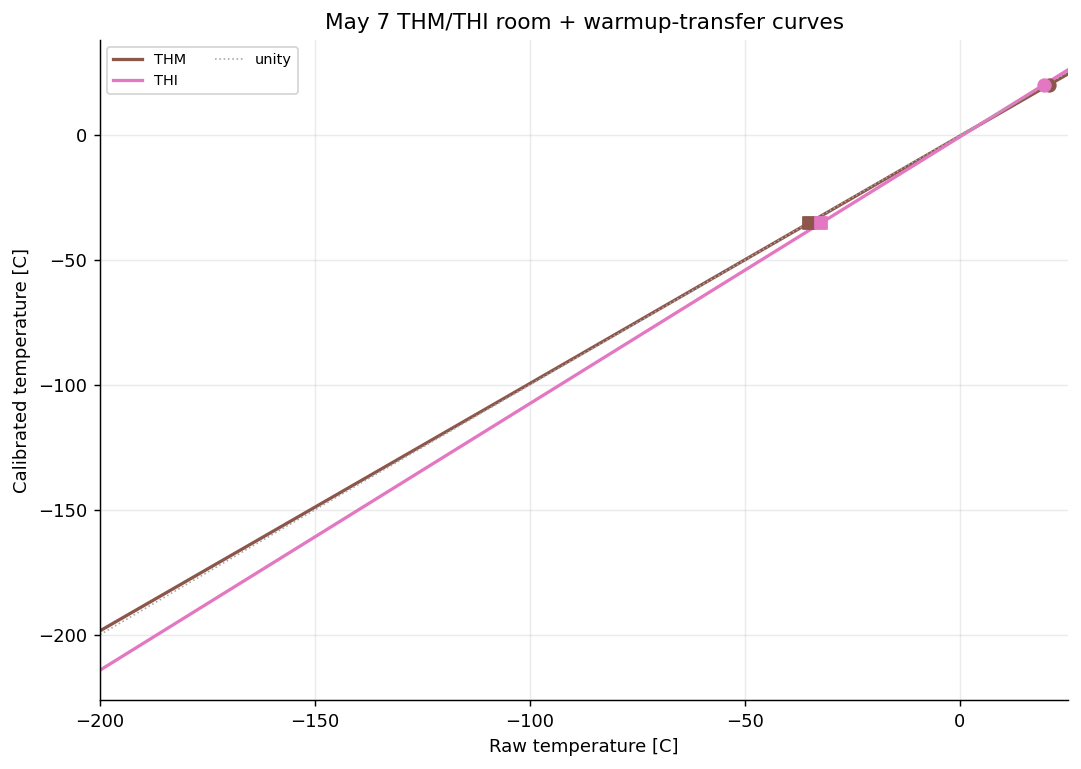

In [4]:

transfer_raw = load_tc_log(MAY7_TRANSFER_LOG)
base_export = apr20_base_table[['TC', 'gain', 'offset_C', 'cal_type']].copy()
transfer_loop_cal = apply_tc_calibration(transfer_raw, base_export, preserve_raw=False)
for column in ['time_s', 'valve', 'pump_cmd_pct', 'TFO_C', 'TTI_C', 'TTO_C', 'TMI_C', 'THM_C', 'THI_C']:
    transfer_loop_cal[column] = pd.to_numeric(transfer_loop_cal[column], errors='coerce')
    transfer_raw[column] = pd.to_numeric(transfer_raw[column], errors='coerce')
transfer_loop_cal['t_rel_min'] = (transfer_loop_cal['time_s'] - float(transfer_loop_cal['time_s'].iloc[0])) / 60.0
transfer_raw['t_rel_min'] = transfer_loop_cal['t_rel_min']

pump_cmd = transfer_loop_cal['pump_cmd_pct'].fillna(0.0)
valve = transfer_loop_cal['valve'].fillna(0.0)
pump_off_min = float(transfer_loop_cal.loc[
    pump_cmd.le(0.0) & pump_cmd.shift(fill_value=float(pump_cmd.iloc[0])).gt(0.0),
    't_rel_min',
].iloc[0])
valve_close_candidates = transfer_loop_cal.loc[
    valve.le(0.0) & valve.shift(fill_value=float(valve.iloc[0])).gt(0.0),
    't_rel_min',
]
valve_close_candidates = valve_close_candidates[valve_close_candidates.lt(pump_off_min)]
cooldown_stop_min = float(valve_close_candidates.iloc[-1])
transfer_start_min = cooldown_stop_min + 5.0

window_mask = transfer_loop_cal['t_rel_min'].ge(transfer_start_min) & transfer_loop_cal['t_rel_min'].lt(pump_off_min)
band_mask = transfer_loop_cal.loc[window_mask, 'TTI_C'].between(-35.5, -34.5)
loop_band = transfer_loop_cal.loc[window_mask].loc[band_mask].copy()
raw_band = transfer_raw.loc[window_mask].loc[band_mask].copy()
if len(loop_band) < 20:
    raise RuntimeError(f'THM/THI transfer band has too few samples: {len(loop_band)}')

loop_reference_cols = ['TFO_C', 'TTI_C', 'TTO_C', 'TMI_C']
loop_reference = loop_band[loop_reference_cols].mean(axis=1)
warmup_reference_c = float(loop_reference.median())
loop_span_c = loop_band[loop_reference_cols].max(axis=1) - loop_band[loop_reference_cols].min(axis=1)

room_raw_map = dict(zip(apr20_base_table['TC'], apr20_base_table['raw_room_C']))
hx_rows = []
hx_anchors = []
for tag in ['THM', 'THI']:
    column = f'{tag}_C'
    raw_room = float(room_raw_map[tag])
    raw_warmup = float(raw_band[column].median())
    gain, offset = two_point(raw_room, raw_warmup, ROOM_REFERENCE_C, warmup_reference_c)
    hx_rows.append({
        'TC': tag,
        'raw_room_C': raw_room,
        'raw_cold_C': raw_warmup,
        'gain': gain,
        'offset_C': offset,
        'cal_type': 'room+warmup-transfer',
        'room_check_C': gain * raw_room + offset,
        'warmup_check_C': gain * raw_warmup + offset,
    })
    hx_anchors.extend([
        {'TC': tag, 'anchor': 'room', 'raw_C': raw_room, 'true_C': ROOM_REFERENCE_C},
        {'TC': tag, 'anchor': 'warmup transfer', 'raw_C': raw_warmup, 'true_C': warmup_reference_c},
    ])

hx_transfer_table = pd.DataFrame(hx_rows)
hx_transfer_anchors = pd.DataFrame(hx_anchors)

transfer_info = pd.DataFrame([{
    'source_log': str(MAY7_TRANSFER_LOG.relative_to(repo_root)),
    'cooldown_stop_min': cooldown_stop_min,
    'transfer_start_min': transfer_start_min,
    'pump_off_min': pump_off_min,
    'band_samples': len(loop_band),
    'loop_reference_C': warmup_reference_c,
    'loop_span_median_C': float(loop_span_c.median()),
    'TTI_band_low_C': -35.5,
    'TTI_band_high_C': -34.5,
}])
display(transfer_info.style.format({
    'cooldown_stop_min': '{:.2f}',
    'transfer_start_min': '{:.2f}',
    'pump_off_min': '{:.2f}',
    'band_samples': '{:.0f}',
    'loop_reference_C': '{:.4f}',
    'loop_span_median_C': '{:.4f}',
    'TTI_band_low_C': '{:.1f}',
    'TTI_band_high_C': '{:.1f}',
}).hide(axis='index'))
display(hx_transfer_table.style.format({
    'raw_room_C': '{:.4f}',
    'raw_cold_C': '{:.4f}',
    'gain': '{:.12f}',
    'offset_C': '{:+.12f}',
    'room_check_C': '{:.4f}',
    'warmup_check_C': '{:.4f}',
}).hide(axis='index'))

fig, ax = plt.subplots(figsize=(10.5, 4.5), constrained_layout=True)
ax.plot(transfer_loop_cal['t_rel_min'], transfer_loop_cal['TTI_C'], color='C2', lw=0.9, label='TTI calibrated')
ax.plot(transfer_loop_cal['t_rel_min'], transfer_loop_cal['TTO_C'], color='C3', lw=0.9, label='TTO calibrated')
ax.plot(transfer_raw['t_rel_min'], transfer_raw['THM_C'], color='C5', lw=0.8, alpha=0.7, label='THM raw')
ax.plot(transfer_raw['t_rel_min'], transfer_raw['THI_C'], color='C6', lw=0.8, alpha=0.7, label='THI raw')
ax.axvspan(transfer_start_min, pump_off_min, color='0.7', alpha=0.12, label='candidate warmup window')
ax.scatter(loop_band['t_rel_min'], loop_band['TTI_C'], s=8, color='black', alpha=0.45, label='selected TTI band')
ax.axhline(warmup_reference_c, color='0.2', lw=0.9, ls='--', label=f'loop reference {warmup_reference_c:.2f} C')
ax.set_xlim(transfer_start_min - 3.0, pump_off_min + 1.0)
ax.set_xlabel('Time from log start [min]')
ax.set_ylabel('Temperature [C]')
ax.set_title('May 7 THM/THI transfer anchor from April 24 warmup segment')
ax.legend(fontsize=8, ncol=3)
plt.show()

fig = plot_calibration_curves(
    hx_transfer_table,
    hx_transfer_anchors,
    'May 7 THM/THI room + warmup-transfer curves',
    columns=['THM', 'THI'],
    raw_limits=(-200.0, ROOM_REFERENCE_C + 5.0),
)
plt.show()


## June 11 calibration


Read 161 TNO rows from log_20260611_155704.csv
Plotting 119 rows from 0-282 seconds
Coldest raw TNO occurs at t = 61.9 s


,t_rel_s,TNO_C,TNO_cal_C
22,52.387,-174.56,-180.918775
23,54.768,-184.82,-191.509697
24,57.150,-187.87,-194.658070
25,59.533,-188.83,-195.649034
26,61.914,-189.17,-196.000000
27,64.293,-188.80,-195.618066
28,66.674,-188.83,-195.649034
29,69.056,-188.89,-195.710969
30,71.438,-188.80,-195.618066


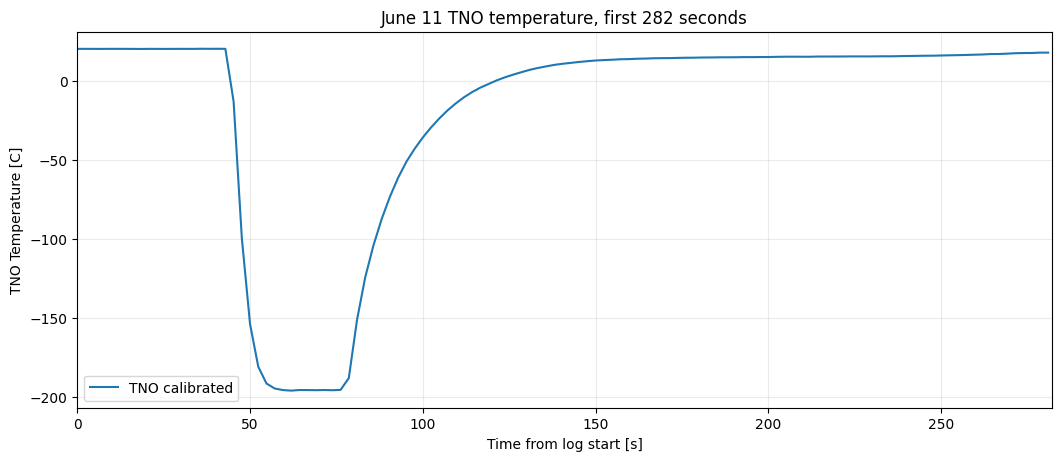

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

repo_root = Path("/home/aamy/Documents/hfe-system")
JUN11_LOG = repo_root / "data" / "raw" / "log_20260611_155704.csv"
JUN11_PLOT_WINDOW_REL_S = (0.0, 282.0)

jun11 = pd.read_csv(JUN11_LOG, comment="#")

jun11["time_s"] = pd.to_numeric(jun11["time_s"], errors="coerce")
jun11["TNO_C"] = pd.to_numeric(jun11["TNO_C"], errors="coerce")

TNO_GAIN = 1.0322536167324254
TNO_OFFSET_C = -0.7285833227270793

jun11["TNO_cal_C"] = TNO_GAIN * jun11["TNO_C"] + TNO_OFFSET_C

jun11 = jun11.dropna(subset=["time_s", "TNO_C", "TNO_cal_C"]).sort_values("time_s").reset_index(drop=True)
jun11["t_rel_s"] = jun11["time_s"] - float(jun11["time_s"].iloc[0])

plot_start_s, plot_end_s = JUN11_PLOT_WINDOW_REL_S
jun11_plot = jun11[jun11["t_rel_s"].between(plot_start_s, plot_end_s)].copy()

print(f"Read {len(jun11)} TNO rows from {JUN11_LOG.name}")
print(f"Plotting {len(jun11_plot)} rows from {plot_start_s:.0f}-{plot_end_s:.0f} seconds")

coldest_tno_idx = jun11_plot["TNO_C"].idxmin()
coldest_tno_s = float(jun11_plot.loc[coldest_tno_idx, "t_rel_s"])
cold_display = jun11_plot.loc[
    jun11_plot["t_rel_s"].between(coldest_tno_s - 10.0, coldest_tno_s + 10.0),
    ["t_rel_s", "TNO_C", "TNO_cal_C"],
]

print(f"Coldest raw TNO occurs at t = {coldest_tno_s:.1f} s")
display(cold_display)

fig, ax = plt.subplots(figsize=(10.5, 4.5), constrained_layout=True)

ax.plot(
    jun11_plot["t_rel_s"],
    jun11_plot["TNO_cal_C"],
    lw=1.5,
    label="TNO calibrated",
)

ax.set_xlim(plot_start_s, plot_end_s)
ax.set_xlabel("Time from log start [s]")
ax.set_ylabel("TNO Temperature [C]")
ax.set_title("June 11 TNO temperature, first 282 seconds")
ax.grid(True, alpha=0.25)
ax.legend()

plt.show()

In [34]:
import numpy as np
import pandas as pd

# Reference values
ROOM_REFERENCE_C = (68.5 - 32.0) * 5.0 / 9.0   # 68.5 F -> 20.2778 C
CRYO_REFERENCE_C = -196.0                      # LN2 reference

# June 11 TNO anchors from the most recent run.
# The cold plunge starts near 45 s, so use only the pre-plunge room section here.
JUN11_ROOM_WINDOW_REL_S = (0.0, 42.0)
raw_cryo_C = -189.17                           # raw TNO cryo reading from the run


def median_tno_in_window(data, window_rel_s):
    start_s, end_s = window_rel_s
    mask = data["t_rel_s"].between(start_s, end_s)
    value = pd.to_numeric(data.loc[mask, "TNO_C"], errors="coerce").median()
    return float(value)


raw_room_C = median_tno_in_window(jun11, JUN11_ROOM_WINDOW_REL_S)

if not np.isfinite(raw_room_C) or not np.isfinite(raw_cryo_C):
    raise RuntimeError(f"Bad calibration anchors: room={raw_room_C}, cryo={raw_cryo_C}")
if np.isclose(raw_room_C, raw_cryo_C):
    raise RuntimeError("Room and cryo raw TNO values are too close to calculate gain.")

# Calibration model: true_C = gain * raw_C + offset_C
tno_gain = (ROOM_REFERENCE_C - CRYO_REFERENCE_C) / (raw_room_C - raw_cryo_C)
tno_offset_C = ROOM_REFERENCE_C - (tno_gain * raw_room_C)
cal_type = "two-point"

jun11_tno_table = pd.DataFrame([{
    "TC": "TNO",
    "raw_room_C": raw_room_C,
    "raw_cryo_C": raw_cryo_C,
    "raw_cold_C": raw_cryo_C,
    "room_reference_C": ROOM_REFERENCE_C,
    "cryo_reference_C": CRYO_REFERENCE_C,
    "gain": tno_gain,
    "offset_C": tno_offset_C,
    "cal_type": cal_type,
    "room_check_C": tno_gain * raw_room_C + tno_offset_C,
    "cryo_check_C": tno_gain * raw_cryo_C + tno_offset_C,
}])

jun11_tno_cal = jun11_tno_table.copy()

display(jun11_tno_table.style.format({
    "raw_room_C": "{:.4f}",
    "raw_cryo_C": "{:.4f}",
    "raw_cold_C": "{:.4f}",
    "room_reference_C": "{:.4f}",
    "cryo_reference_C": "{:.4f}",
    "gain": "{:.12f}",
    "offset_C": "{:+.12f}",
    "room_check_C": "{:.4f}",
    "cryo_check_C": "{:.4f}",
}).hide(axis="index"))


TC,raw_room_C,raw_cryo_C,raw_cold_C,room_reference_C,cryo_reference_C,gain,offset_C,cal_type,room_check_C,cryo_check_C
TNO,20.3500,-189.1700,-189.1700,20.2778,-196.0000,1.032253616732,-0.728583322727,two-point,20.2778,-196.0000


## Active Export

The active table keeps the April 20 Type T rows, replaces the April 20 room-only HX placeholders with the May 7 `THM`/`THI` room + warmup-transfer rows, and adds the June 11 `TNO` two-point calibration. This file is the one consumed by the supervisor UI and analysis notebooks.

In [ ]:

final_table = apr20_base_table[['TC', 'gain', 'offset_C', 'cal_type']].copy()
for replacement_table in [hx_transfer_table, jun11_tno_table]:
    for _, row in replacement_table.iterrows():
        replacement = row[['TC', 'gain', 'offset_C', 'cal_type']].to_frame().T
        mask = final_table['TC'].eq(row['TC'])
        if mask.any():
            final_table.loc[mask, ['gain', 'offset_C', 'cal_type']] = row[['gain', 'offset_C', 'cal_type']].to_numpy()
        else:
            final_table = pd.concat([final_table, replacement], ignore_index=True)

active_export = export_table(final_table, ACTIVE_EXPORT)
print(f'Saved active calibration -> {ACTIVE_EXPORT.relative_to(repo_root)}')
display(active_export.style.format({'gain': '{:.12f}', 'offset_C': '{:+.12f}'}).hide(axis='index'))


## Use Summary
- `TC_calibration_20260410.csv` is historical because the April 10 Type T low-temperature readings were decoded with the wrong thermocouple table.
- `TC_calibration_20260420.csv` is active. Its Type T rows come from the April 20 corrected-type calibration log.
- The active `THM`/`THI` rows are channel-first May 7 transfer fits: April 20 room anchor plus April 24 in-system warmup anchor near `-35 C`.